## Dataset Variables
H2H2 collisions dataset by Benjamin contains the following columns: b,Etr,Er1,Er2,Etrp,Er1p,Er2p.

# Mixeture Density Networks (MDN)

A Mixture Density Network (MDN) predicts means, variances, and mixture coefficients for a mixture of Gaussian distributions, allowing it to model complex output distributions conditioned on input features. This is particularly useful for modeling the scattering kernel in our oxygen dataset, where the output velocity distributions depend on the input velocities.

The MDN creates a model that predicts conditional probabilities using
$$ 
p(y|x) = \sum_{i=1}^{K} \pi_i(x) \mathcal{N}(y|\mu_i(x), \sigma_i(x)) 
$$
where $K$ is the number of mixture components, $\pi_i(x)$ are the mixture coefficients, and $\mathcal{N}(y|\mu_i(x), \sigma_i(x))$ are Gaussian distributions with means $\mu_i(x)$ and standard deviations $\sigma_i(x)$.

The dimensions of each variable is:
$\pi$: K
$\mu$: K x D
$\sigma$: K x D
where D is the output dimension.

#### Dataset Preparation

Input mean: [6049.673828125, 0.4815983474254608, 0.5023599863052368]
Input std : [2097.983154296875, 0.1984938532114029, 0.23896823823451996]
Output mean: [0.48537585139274597, 0.5032348036766052]
Output std : [0.21043580770492554, 0.25154367089271545]
Epoch 1, Training Loss: 2.9316
Epoch 1, Validation Loss: 2.7692
Epoch 2, Training Loss: 2.6095
Epoch 2, Validation Loss: 2.4799
Epoch 3, Training Loss: 2.3320
Epoch 3, Validation Loss: 2.1702
Epoch 4, Training Loss: 1.9398
Epoch 4, Validation Loss: 1.6607
Epoch 5, Training Loss: 1.4476
Epoch 5, Validation Loss: 1.2443
Epoch 6, Training Loss: 1.1834
Epoch 6, Validation Loss: 1.0347
Epoch 7, Training Loss: 1.0253
Epoch 7, Validation Loss: 0.8845
Epoch 8, Training Loss: 0.9125
Epoch 8, Validation Loss: 0.7830
Epoch 9, Training Loss: 0.8877
Epoch 9, Validation Loss: 0.7827
Epoch 10, Training Loss: 0.7960
Epoch 10, Validation Loss: 0.6649
Epoch 11, Training Loss: 0.7536
Epoch 11, Validation Loss: 0.6793
Epoch 12, Training Loss: 0.7499
Epoch 1

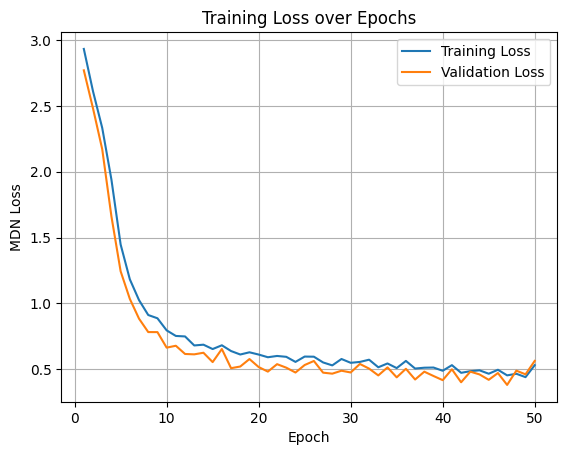

In [24]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset, Subset
import torch.nn as nn
import torch.nn.functional as F

# import data
DATA = "datasets/H2H2_collisions_benjamin.csv"
rawdata = np.loadtxt(DATA, delimiter=',', skiprows=1)

# Convert to the variable set (Ec, \eta_trans, \eta_rot_A)
inputdata = np.zeros((rawdata.shape[0], 3))
inputdata[:,0] = np.sum(rawdata[:,1:4], axis=1)
inputdata[:,1] = rawdata[:,1]/inputdata[:,0] 
inputdata[:,2] = rawdata[:,2] / np.sum(rawdata[:,2:4], axis=1)

outputdata = np.zeros((rawdata.shape[0], 2))
# outputdata[:,0] = np.sum(rawdata[:,4:7], axis=1)
outputdata[:,0] = rawdata[:,4]/np.sum(rawdata[:,4:7], axis=1)
outputdata[:,1] = rawdata[:,5]/ np.sum(rawdata[:,5:7], axis=1)

# Create Dataloaders for training and validation (with normalization)
inputs = torch.tensor(inputdata, dtype=torch.float32)
outputs = torch.tensor(outputdata, dtype=torch.float32)

dataset = TensorDataset(inputs, outputs)

# Set machine learning parameters
train_size = int(0.7 * len(dataset))
val_size = len(dataset) - train_size
batch_size = 128

# Create train/validation split 
generator = torch.Generator().manual_seed(0)
train_subset, val_subset = torch.utils.data.random_split(dataset, [train_size, val_size], generator=generator)

train_idx = torch.tensor(train_subset.indices, dtype=torch.long)
val_idx = torch.tensor(val_subset.indices, dtype=torch.long)

# Compute normalization statistics on training data only
eps = 1e-8
in_mean = inputs[train_idx].mean(dim=0, keepdim=True)
in_std = inputs[train_idx].std(dim=0, unbiased=False, keepdim=True).clamp_min(eps)
out_mean = outputs[train_idx].mean(dim=0, keepdim=True)
out_std = outputs[train_idx].std(dim=0, unbiased=False, keepdim=True).clamp_min(eps)

# Normalize tensors, then re-wrap
inputs_norm = (inputs - in_mean) / in_std
outputs_norm = (outputs - out_mean) / out_std
dataset_norm = TensorDataset(inputs_norm, outputs_norm)

train_dataset = Subset(dataset_norm, train_idx.tolist())
val_dataset = Subset(dataset_norm, val_idx.tolist())

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

print("Input mean:", in_mean.flatten().tolist())
print("Input std :", in_std.flatten().tolist())
print("Output mean:", out_mean.flatten().tolist())
print("Output std :", out_std.flatten().tolist())

# Model Definition
class MixtureDensityNetwork(nn.Module):
    def __init__(self, input_dim, output_dim, num_mixtures, hidden_dim=128):
        super().__init__()
        self.K = num_mixtures
        self.D = output_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.pi_layer = nn.Linear(hidden_dim, self.K)
        self.mu_layer = nn.Linear(hidden_dim, self.K * self.D)
        self.sigma_layer = nn.Linear(hidden_dim, self.K * self.D)

    def forward(self, x):
        h = self.net(x)

        # Mixture weights
        pi = F.softmax(self.pi_layer(h), dim=-1)

        # Means
        mu = self.mu_layer(h)
        mu = mu.view(-1, self.K, self.D)

        # Standard deviations
        sigma = self.sigma_layer(h)
        sigma = F.softplus(sigma) + 1e-6  # Ensure positivity
        # sigma = torch.exp(sigma)
        sigma = sigma.view(-1, self.K, self.D)

        return pi, mu, sigma

# Define loss function
def mdn_loss(pi, mu, sigma, y):
    """
    Computes the negative log-likelihood loss for a Mixture Density Network.
    Args:
        pi: Mixture weights, shape (batch_size, K)
        mu: Means of the mixtures, shape (batch_size, K, D)
        sigma: Standard deviations of the mixtures, shape (batch_size, K, D)
        y: Target values, shape (batch_size, D)
    """
    y = y.unsqueeze(1)  # Shape (batch_size, 1, D)

    # Gaussian probability density function
    log_prob = -0.5 * (
        torch.sum(((y - mu) / sigma) ** 2, dim=2)
        + torch.sum(torch.log(sigma ** 2), dim=2)
        + mu.size(2) * torch.log(torch.tensor(2 * torch.pi))
    )  # Shape (batch_size, K)

    # Weighted log probabilities
    weighted_log_prob = log_prob + torch.log(pi + 1e-8)
    log_sum_exp = torch.logsumexp(weighted_log_prob, dim=1) 

    return -torch.mean(log_sum_exp)

# Training the model
K = 20
output_vars = 2

model = MixtureDensityNetwork(
    input_dim=3,
    output_dim=output_vars,
    num_mixtures=K
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 50
train_loss_hist = np.zeros(num_epochs)
val_loss_hist = np.zeros(num_epochs)

for epoch in range(num_epochs):
    # Training loop
    model.train()
    train_loss = 0.0
    for inputs, outputs in train_loader:
        optimizer.zero_grad()
        pi, mu, sigma = model(inputs)
        loss = mdn_loss(pi, mu, sigma, outputs)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_loss_hist[epoch] = train_loss
    print(f"Epoch {epoch+1}, Training Loss: {train_loss:.4f}")

    # Validation loop
    model.eval()
    with torch.no_grad():
        val_loss = 0.0
        for inputs, outputs in val_loader:
            pi, mu, sigma = model(inputs)
            loss = mdn_loss(pi, mu, sigma, outputs)
            val_loss += loss.item()

        val_loss /= len(val_loader)
        val_loss_hist[epoch] = val_loss
    print(f"Epoch {epoch+1}, Validation Loss: {val_loss_hist[epoch]:.4f}")

# save model
torch.save(model.state_dict(), "mdn_h2h2_collision_model.pth")


# Plot loss
import matplotlib.pyplot as plt

plt.plot(range(1, num_epochs + 1), train_loss_hist, label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_loss_hist, label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('MDN Loss')
plt.title('Training Loss over Epochs')
plt.grid()
plt.show()

In [27]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Sample from the trained MDN (handles the same normalization used during training)
def sample_mdn(model, inputdata, in_mean, in_std, out_mean, out_std):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(inputdata, dtype=torch.float32)
        x = (x - in_mean) / in_std
        pi, mu, sigma = model(x)

        # Move to CPU numpy for sampling
        pi_np = pi.detach().cpu().numpy()
        mu_np = mu.detach().cpu().numpy()
        sigma_np = sigma.detach().cpu().numpy()

        out_mean_np = out_mean.detach().cpu().numpy().reshape(-1)
        out_std_np = out_std.detach().cpu().numpy().reshape(-1)

        # N is number of data points, K is number of mixtures, D is output dimension
        N, K, D = mu_np.shape
        samples = np.zeros((N, D), dtype=np.float32)

        for i in range(N):
            component = np.random.choice(K, p=pi_np[i])
            y_norm = np.random.normal(loc=mu_np[i, component], scale=sigma_np[i, component])
            # Denormalize back to original output space
            y = y_norm * out_std_np + out_mean_np
            samples[i] = y

    return samples


def plot_scattering_comparison(ctc_data, mdn_model):
    """Visualize the comparison between CTC scattering data and MDN model predictions.
    Args:
        ctc_data (np.ndarray): array of shape (N, 5) with columns
            [E_c, eta_tr_in, eta_r_A_in, eta_tr_out, eta_r_A_out].
        mdn_model (MixtureDensityNetwork): trained MDN model for predictions.
    """
    samples = sample_mdn(
        model=mdn_model,
        inputdata=ctc_data[:, :3],
        in_mean=in_mean,
        in_std=in_std,
        out_mean=out_mean,
        out_std=out_std,
    )

    dotsize = 4
    alpha = 1.0
    colormap = 'viridis'
    fig, ax = plt.subplots(2, 2, figsize=(10, 10))

    # CTC ground truth
    ax[0, 0].set_title('CTC Data')
    xy1 = np.vstack([ctc_data[:, 1], ctc_data[:, 3]])
    z1 = gaussian_kde(xy1)(xy1)   # density per point
    idx1 = z1.argsort()          # plot low-density first
    x1, y1 = ctc_data[:, 1][idx1], ctc_data[:, 3][idx1]
    ax[0, 0].scatter(x1, y1, c=z1[idx1], cmap=colormap, alpha=alpha, s=dotsize)
    ax[0,0].set_ylim(0,1)
    ax[0,0].set_xlim(0,1)
    ax[0, 0].set_xlabel(r"$\eta_{tr}$")
    ax[0, 0].set_ylabel(r"$\eta_{tr}'$")

    xy2 = np.vstack([ctc_data[:, 2], ctc_data[:, 4]])
    z2 = gaussian_kde(xy2)(xy2)   # density per point
    idx2 = z2.argsort()          # plot low-density first
    x2, y2 = ctc_data[:, 2][idx2], ctc_data[:, 4][idx2]
    ax[1, 0].scatter(x2, y2, c=z2[idx2], cmap=colormap, alpha=alpha, s=dotsize)
    ax[1,0].set_ylim(0,1)
    ax[1,0].set_xlim(0,1)
    ax[1, 0].set_xlabel(r"$\eta_{r,A}$")
    ax[1, 0].set_ylabel(r"$\eta_{r,A}'$")

    # MDN predictions
    ax[0, 1].set_title('MDN Predictions')
    xy3 = np.vstack([ctc_data[:, 1], samples[:, 0]])
    z3 = gaussian_kde(xy3)(xy3)   # density per point
    idx3 = z3.argsort()          # plot low-density first
    x3, y3 = ctc_data[:, 1][idx3], samples[:, 0][idx3]
    ax[0, 1].scatter(x3, y3, c=z3[idx3], cmap=colormap, alpha=alpha, s=dotsize)
    ax[0,1].set_ylim(0,1)
    ax[0,1].set_xlim(0,1)
    ax[0, 1].set_xlabel(r"$\eta_{tr}$")
    ax[0, 1].set_ylabel(r"$\eta_{tr}'$")

    xy4 = np.vstack([ctc_data[:, 2], samples[:, 1]])
    z4 = gaussian_kde(xy4)(xy4)   # density per point
    idx4 = z4.argsort()          # plot low-density first
    x4, y4 = ctc_data[:, 2][idx4], samples[:, 1][idx4]
    ax[1, 1].scatter(x4, y4, c=z4[idx4], cmap=colormap, alpha=alpha, s=dotsize)
    ax[1,1].set_ylim(0,1)
    ax[1,1].set_xlim(0,1)
    ax[1, 1].set_xlabel(r"$\eta_{r,A}$")
    ax[1, 1].set_ylabel(r"$\eta_{r,A}'$")

    plt.tight_layout()
    plt.show()

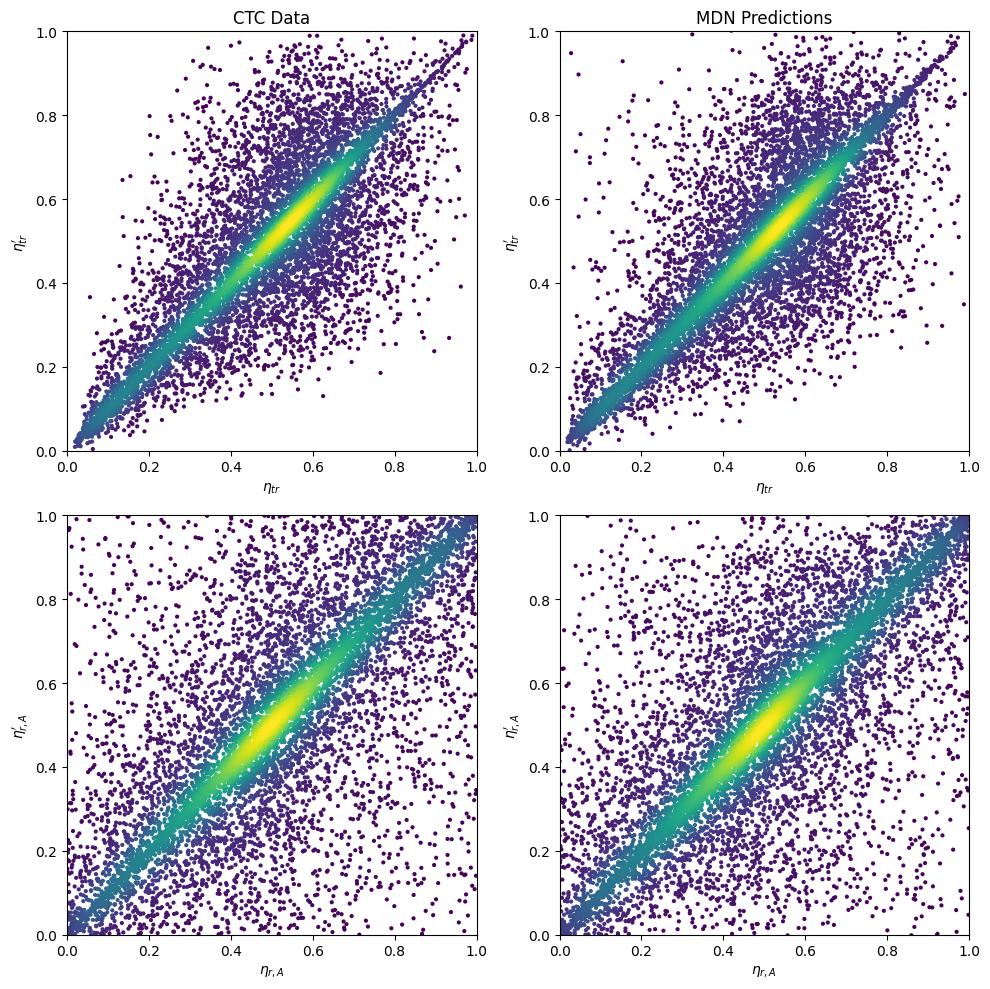

In [28]:
mdn_model = MixtureDensityNetwork(
    input_dim=3,
    output_dim=2,
    num_mixtures=K
)
mdn_model.load_state_dict(
    torch.load("mdn_h2h2_collision_model.pth")
)


# plot comparison
plot_scattering_comparison(np.column_stack((inputdata, outputdata)),mdn_model)